# Image Segmentation with U-Net
## Optimized for Google Colab T4 GPU

**Author:** Ganapathi Kakarla  
**Date:** 2026  
**GPU:** T4 (16GB)  

This notebook implements binary image segmentation using U-Net architecture with ResNet34 encoder.

## 1. Check GPU Availability

In [ ]:
import torch
import gc

# Check GPU
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU not available! Go to Runtime -> Change runtime type -> Select GPU")

PyTorch Version: 2.9.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: Tesla T4
GPU Memory: 15.83 GB


## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Install Required Libraries

In [ ]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless
print("✓ Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00
✓ Libraries installed successfully!


## 4. Import Libraries

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Segmentation Models
!pip install -q segmentation-models-pytorch # Added installation command here
import segmentation_models_pytorch as smp

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 5. Configuration & Paths

In [ ]:
# ========== MODIFY THESE PATHS ==========
BASE = '/content/drive/MyDrive/Segmentation'  # Change this to your folder

TRAIN_IMG_DIR = f"{BASE}/train_images"
TRAIN_MASK_DIR = f"{BASE}/train_masks"
TEST_IMG_DIR = f"{BASE}/test_images"
TEST_MASK_DIR = f"{BASE}/test_masks"
OUTPUT_DIR = f"{BASE}/outputs"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== HYPERPARAMETERS ==========
IMAGE_SIZE = 256          # Image dimensions (256x256)
BATCH_SIZE = 8            # Batch size (T4 GPU can handle 8-16)
LEARNING_RATE = 1e-4      # Learning rate
EPOCHS = 20               # Number of epochs (reasonable for testing)
NUM_WORKERS = 2           # Data loading workers

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Device: {DEVICE}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

Device: cuda
Image Size: 256x256
Batch Size: 8
Epochs: 20
Learning Rate: 0.0001


## 6. Dataset Class

In [ ]:
class SegmentationDataset(Dataset):
    """
    Custom Dataset for Image Segmentation

    Args:
        img_dir: Directory containing images
        mask_dir: Directory containing masks
        transform: Albumentations transform pipeline
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Filter images to ensure corresponding masks exist
        self.images = []
        for img_name in sorted(os.listdir(img_dir)):
            img_path = os.path.join(self.img_dir, img_name)
            mask_path = os.path.join(self.mask_dir, img_name)
            if os.path.exists(img_path) and os.path.exists(mask_path):
                self.images.append(img_name)
            else:
                print(f"Skipping {img_name}: missing image or mask file.")

        if not self.images:
            raise RuntimeError(f"No valid image-mask pairs found in {img_dir} and {mask_dir}.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        # Load image (BGR -> RGB)
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask (grayscale)
        mask_path = os.path.join(self.mask_dir, img_name)
        mask = cv2.imread(mask_path, 0)

        # Normalize mask to [0, 1]
        mask = mask / 255.0

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Add channel dimension to mask: (H, W) -> (1, H, W)
        mask = mask.unsqueeze(0).float()

        return img, mask

print("✓ Dataset class defined!")

✓ Dataset class defined!


## 7. Data Augmentation

In [ ]:
# Training transforms (with augmentation)
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    ),
    ToTensorV2()
])

# Test/Validation transforms (no augmentation)
test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print("✓ Transforms defined!")

✓ Transforms defined!


## 8. Create Datasets and DataLoaders

In [ ]:
# Create datasets
train_dataset = SegmentationDataset(
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    transform=train_transform
)

test_dataset = SegmentationDataset(
    TEST_IMG_DIR,
    TEST_MASK_DIR,
    transform=test_transform
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True  # Faster CPU->GPU transfer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")
print(f"✓ Training batches: {len(train_loader)}")
print(f"✓ Test batches: {len(test_loader)}")

Skipping wsnet_0784 (1).png: missing image or mask file.
Skipping wsnet_1099 (1).png: missing image or mask file.
Skipping wsnet_1102 (1).png: missing image or mask file.
Skipping wsnet_1103 (1).png: missing image or mask file.
Skipping wsnet_1104 (1).png: missing image or mask file.
Skipping wsnet_1105 (1).png: missing image or mask file.
Skipping wsnet_1106 (1).png: missing image or mask file.
Skipping wsnet_1107 (1).png: missing image or mask file.
Skipping wsnet_1108 (1).png: missing image or mask file.
✓ Training samples: 2208
✓ Test samples: 552
✓ Training batches: 276
✓ Test batches: 69


## 9. Visualize Sample Data

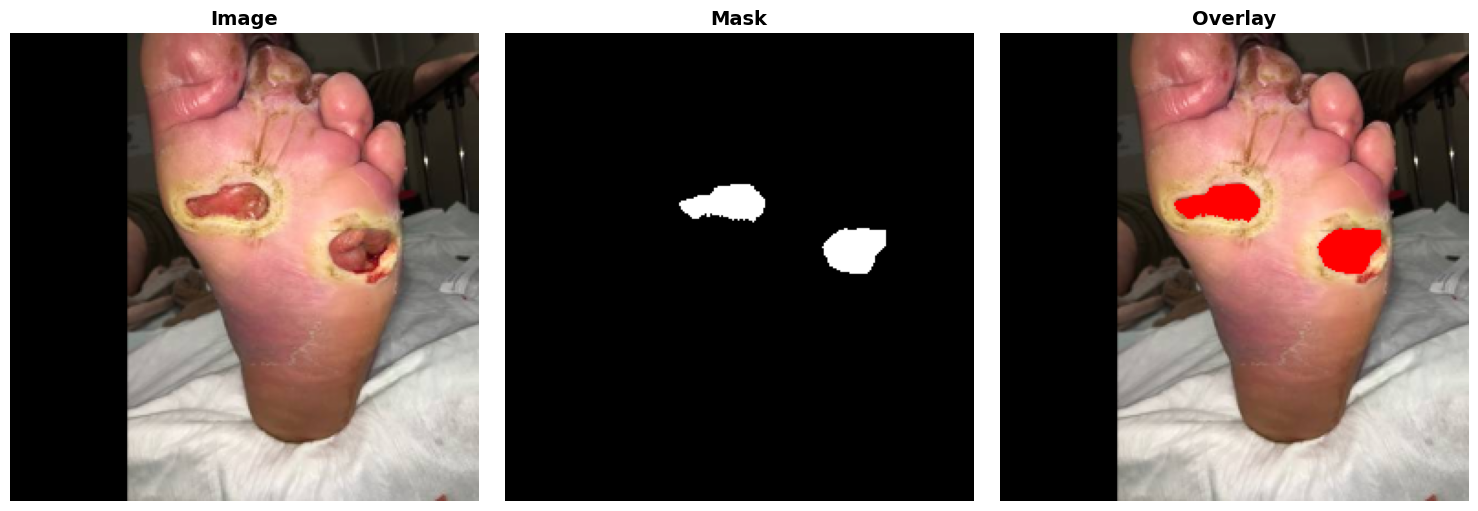

Sample 456 visualized


In [ ]:
def denormalize(tensor, mean, std):
    """Denormalize tensor for visualization"""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Get a random sample
idx = random.randint(0, len(train_dataset) - 1)
img, mask = train_dataset[idx]

# Denormalize image
img_display = denormalize(
    img.clone(),
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
img_display = img_display.permute(1, 2, 0).numpy()
img_display = np.clip(img_display, 0, 1)

# Convert mask to displayable format
mask_display = mask.squeeze().numpy()

# Create overlay
overlay = img_display.copy()
overlay[mask_display > 0.5] = [1, 0, 0]  # Red color for mask

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display)
axes[0].set_title('Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_display, cmap='gray')
axes[1].set_title('Mask', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Overlay', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f"Sample {idx} visualized")

## 10. Define Model

In [ ]:
# Create U-Net model with ResNet34 encoder
model = smp.Unet(
    encoder_name="resnet34",        # Encoder backbone
    encoder_weights="imagenet",     # Pretrained on ImageNet
    in_channels=3,                  # RGB input
    classes=1                       # Binary segmentation
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model created: U-Net with ResNet34 encoder")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1e6:.1f} MB")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✓ Model created: U-Net with ResNet34 encoder
  Total parameters: 24,436,369
  Trainable parameters: 24,436,369
  Model size: ~97.7 MB


## 11. Loss Function and Optimizer

In [ ]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional but recommended)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Mixed precision training scaler (for faster training)
scaler = GradScaler()

print("✓ Loss function: BCEWithLogitsLoss")
print("✓ Optimizer: Adam")
print("✓ Scheduler: ReduceLROnPlateau")
print("✓ Mixed Precision: Enabled")

✓ Loss function: BCEWithLogitsLoss
✓ Optimizer: Adam
✓ Scheduler: ReduceLROnPlateau
✓ Mixed Precision: Enabled


## 12. Evaluation Metrics

In [ ]:
def calculate_iou(pred, target, threshold=0.5):
    """
    Calculate Intersection over Union (IoU)

    Args:
        pred: Predicted masks (after sigmoid)
        target: Ground truth masks
        threshold: Threshold for binary prediction

    Returns:
        IoU score
    """
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-8) / (union + 1e-8)
    return iou.item()

def calculate_f1(pred, target, threshold=0.5):
    """
    Calculate F1-score (Dice coefficient)

    Args:
        pred: Predicted masks (after sigmoid)
        target: Ground truth masks
        threshold: Threshold for binary prediction

    Returns:
        F1-score
    """
    pred = (pred > threshold).float()
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    f1 = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    return f1.item()

print("✓ Metrics defined: IoU and F1-score")

✓ Metrics defined: IoU and F1-score


## 13. Training Loop

In [ ]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_f1': []
}

best_iou = 0.0

print("Starting training...\n")

for epoch in range(EPOCHS):
    # ========== TRAINING PHASE ==========
    model.train()
    train_loss = 0.0

    # Progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, masks in pbar:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        # Mixed precision training
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)

    # ========== VALIDATION PHASE ==========
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_f1 = 0.0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            # Apply sigmoid for metrics
            outputs_sigmoid = torch.sigmoid(outputs)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs_sigmoid, masks)
            val_f1 += calculate_f1(outputs_sigmoid, masks)

    avg_val_loss = val_loss / len(test_loader)
    avg_val_iou = val_iou / len(test_loader)
    avg_val_f1 = val_f1 / len(test_loader)

    # Update learning rate
    scheduler.step(avg_val_loss)

    # Save history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)
    history['val_f1'].append(avg_val_f1)

    # Print epoch results
    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val IoU:    {avg_val_iou:.4f}")
    print(f"  Val F1:     {avg_val_f1:.4f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pth')
        print(f"  ✓ Best model saved! (IoU: {best_iou:.4f})")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, f'{OUTPUT_DIR}/checkpoint_epoch_{epoch+1}.pth')
        print(f"  ✓ Checkpoint saved!")

    print("-" * 50)

    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

print("\n✓ Training completed!")
print(f"Best IoU: {best_iou:.4f}")

Starting training...



Epoch 1/20 [Train]:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 1/20 [Val]  :   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 1/20:
  Train Loss: 0.4080
  Val Loss:   0.1875
  Val IoU:    0.3574
  Val F1:     0.5095
  LR:         0.000100
  ✓ Best model saved! (IoU: 0.3574)
--------------------------------------------------


Epoch 2/20 [Train]:   0%|          | 0/276 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]  :   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 19/20:
  Train Loss: 0.0403
  Val Loss:   0.0112
  Val IoU:    0.7063
  Val F1:     0.8245
  LR:         0.000100
--------------------------------------------------


Epoch 20/20 [Train]:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 20/20 [Val]  :   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 20/20:
  Train Loss: 0.0423
  Val Loss:   0.0105
  Val IoU:    0.7517
  Val F1:     0.8563
  LR:         0.000100
  ✓ Checkpoint saved!
--------------------------------------------------

✓ Training completed!
Best IoU: 0.7624


## 14. Save Final Model

In [ ]:
# Save final model
torch.save(model.state_dict(), f'{OUTPUT_DIR}/final_model.pth')
print(f"✓ Final model saved to {OUTPUT_DIR}/final_model.pth")

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()
print("✓ GPU memory cleared")

✓ Final model saved to /content/drive/MyDrive/Segmentation/outputs/final_model.pth
✓ GPU memory cleared


## 15. Plot Training History

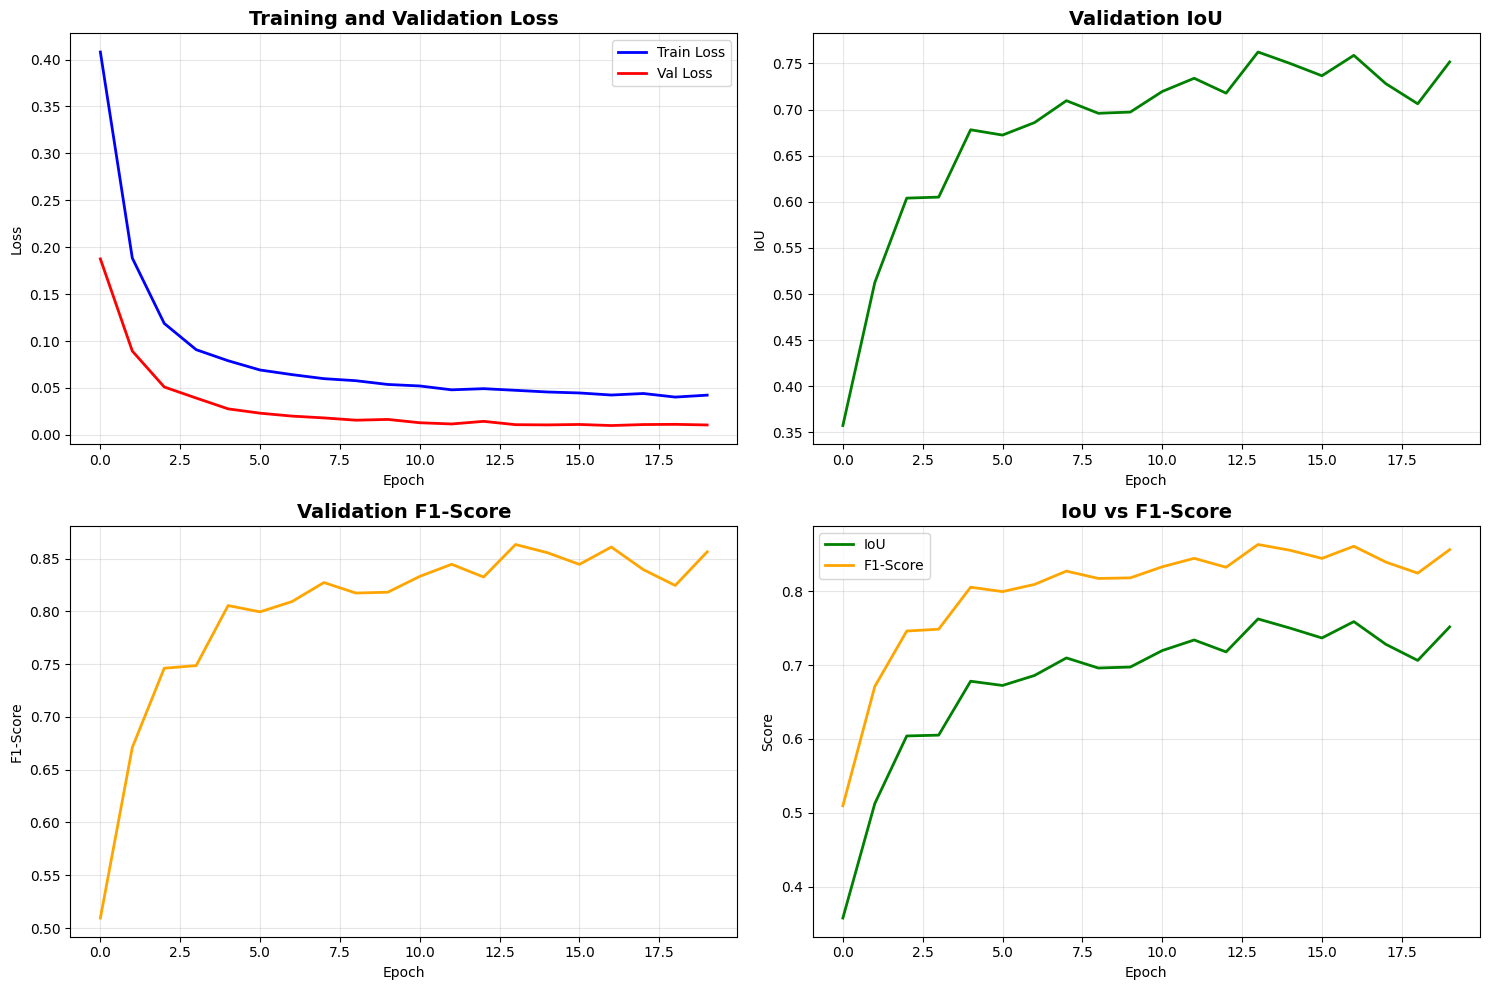

✓ Training history saved to /content/drive/MyDrive/Segmentation/outputs/training_history.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0, 0].plot(history['val_loss'], 'r-', linewidth=2, label='Val Loss')
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# IoU curve
axes[0, 1].plot(history['val_iou'], 'g-', linewidth=2)
axes[0, 1].set_title('Validation IoU', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].grid(True, alpha=0.3)

# F1 curve
axes[1, 0].plot(history['val_f1'], 'orange', linewidth=2)
axes[1, 0].set_title('Validation F1-Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].grid(True, alpha=0.3)

# Metrics comparison
axes[1, 1].plot(history['val_iou'], 'g-', linewidth=2, label='IoU')
axes[1, 1].plot(history['val_f1'], 'orange', linewidth=2, label='F1-Score')
axes[1, 1].set_title('IoU vs F1-Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training history saved to {OUTPUT_DIR}/training_history.png")

## 16. Load Best Model

In [ ]:
# Load best model for evaluation
model.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_model.pth'))
model.eval()
print("✓ Best model loaded for evaluation")

✓ Best model loaded for evaluation


## 17. Visualize Predictions

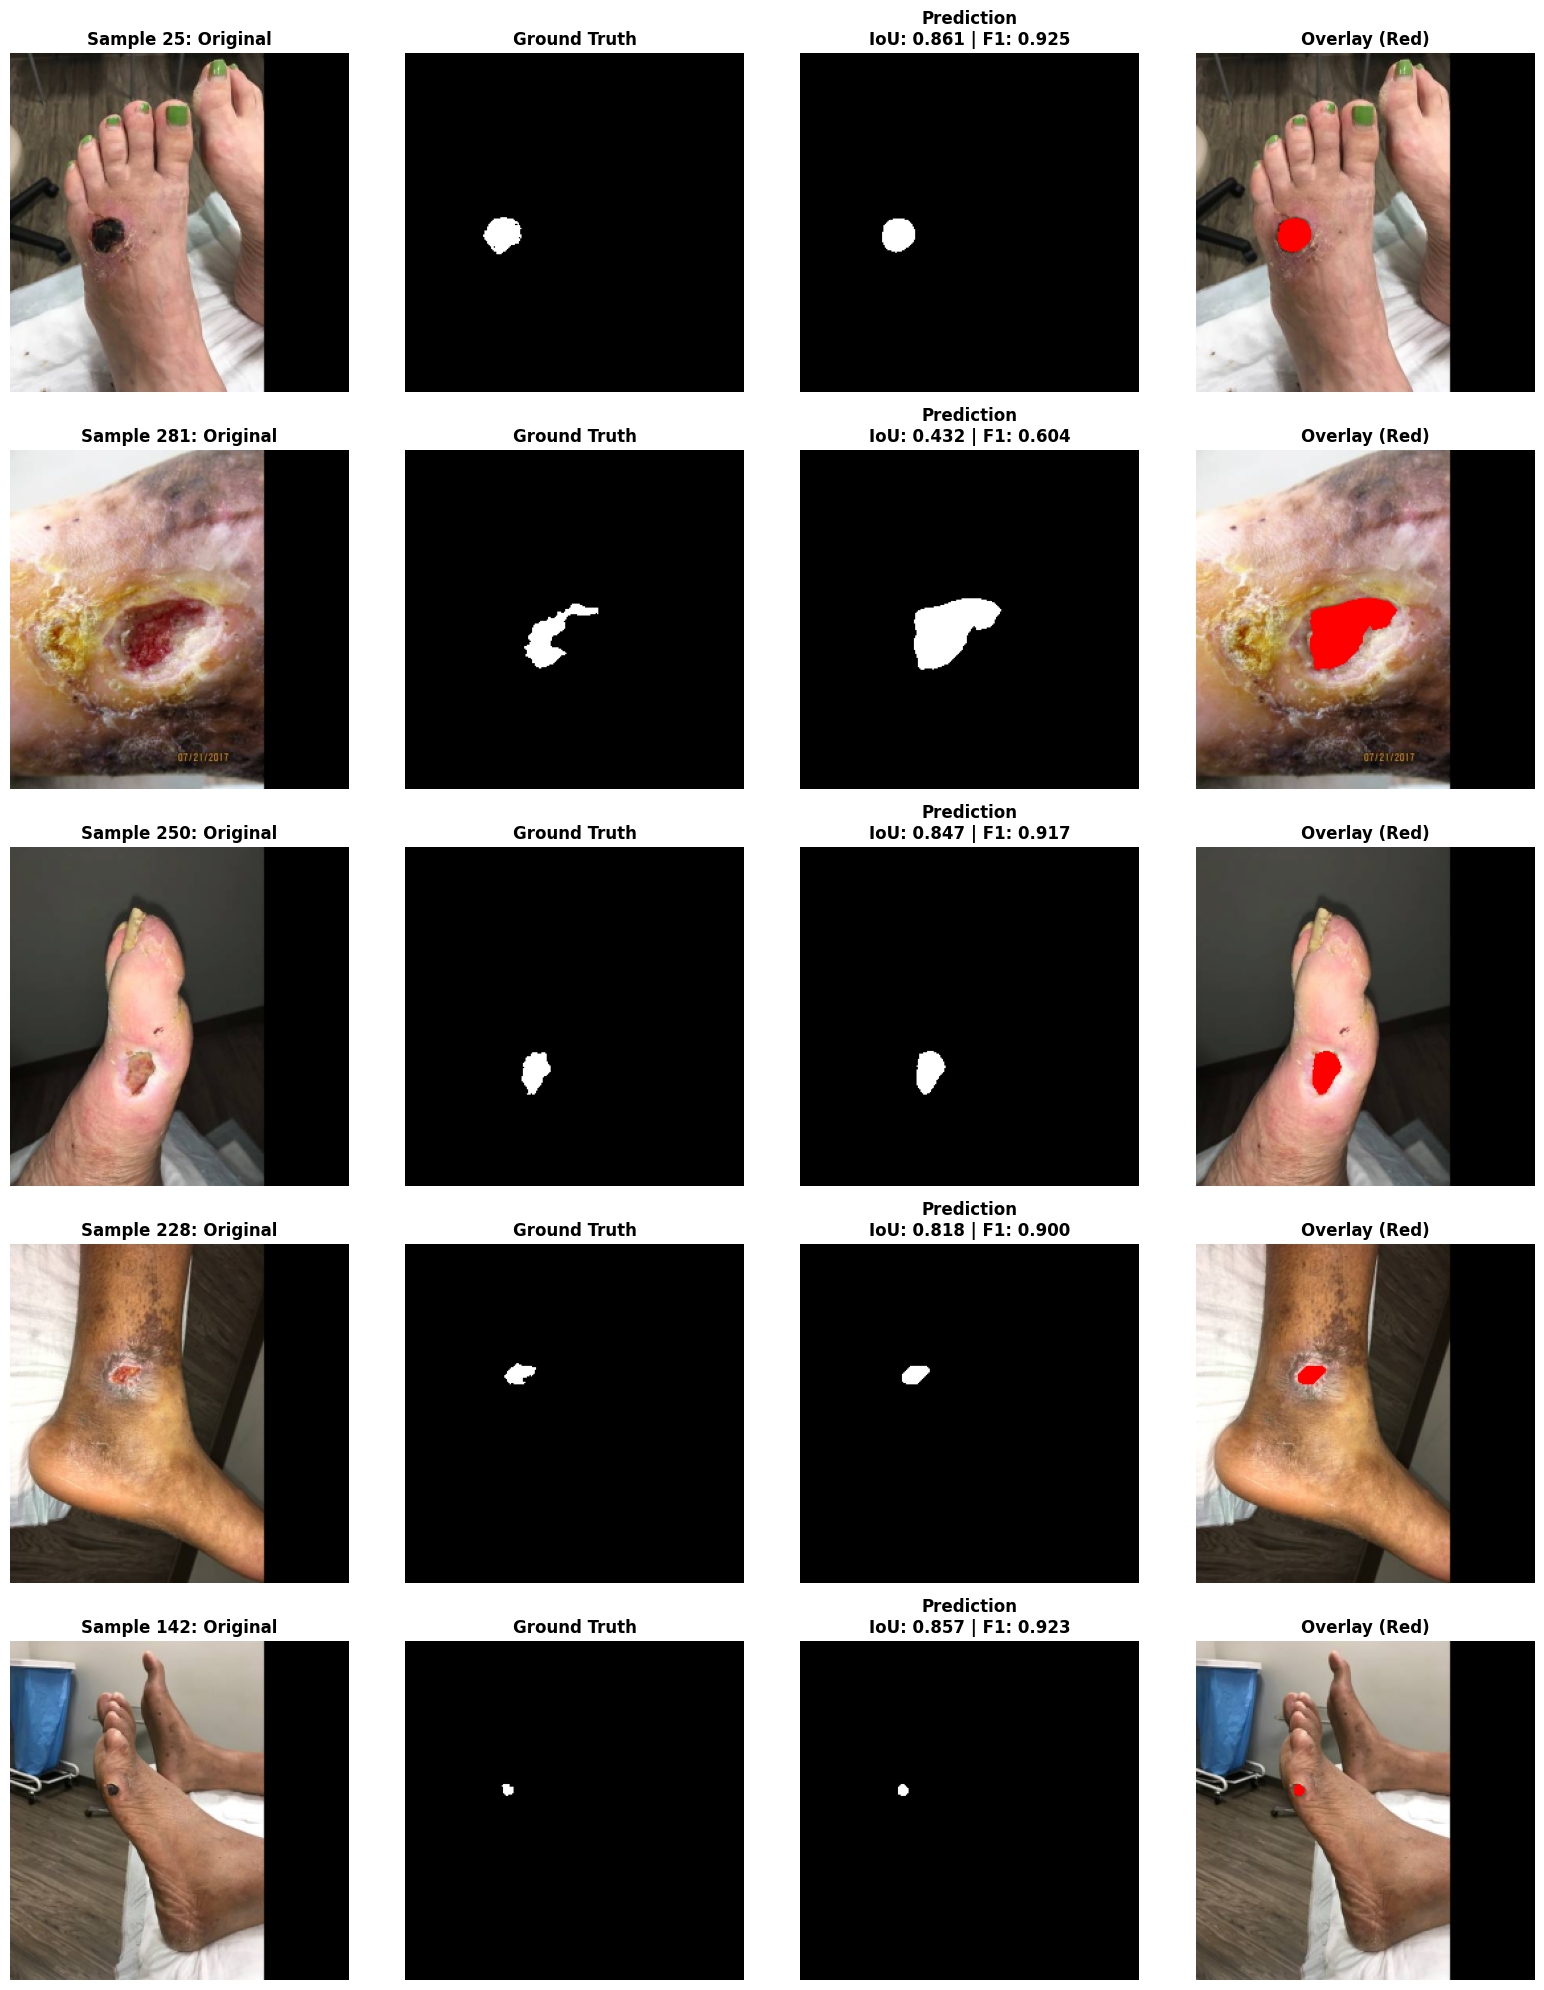

✓ Predictions saved to /content/drive/MyDrive/Segmentation/outputs/predictions.png


In [ ]:
num_samples = 5
random_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Get image and mask
        img, mask = test_dataset[idx]

        # Predict
        img_tensor = img.unsqueeze(0).to(DEVICE)
        pred = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
        pred_binary = (pred > 0.5).astype(np.uint8) * 255

        # Denormalize image
        img_display = denormalize(
            img.clone(),
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        img_display = img_display.permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        # Ground truth mask
        mask_display = (mask.squeeze().numpy() * 255).astype(np.uint8)

        # Create overlays
        overlay_gt = img_display.copy()
        overlay_gt[mask_display > 127] = [0, 1, 0]  # Green for ground truth

        overlay_pred = img_display.copy()
        overlay_pred[pred_binary > 127] = [1, 0, 0]  # Red for prediction

        # Calculate metrics for this sample
        sample_iou = calculate_iou(
            torch.from_numpy(pred).unsqueeze(0),
            mask
        )
        sample_f1 = calculate_f1(
            torch.from_numpy(pred).unsqueeze(0),
            mask
        )

        # Plot
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'Sample {idx}: Original', fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_display, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontweight='bold')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_binary, cmap='gray')
        axes[i, 2].set_title(f'Prediction\nIoU: {sample_iou:.3f} | F1: {sample_f1:.3f}', fontweight='bold')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(overlay_pred)
        axes[i, 3].set_title('Overlay (Red)', fontweight='bold')
        axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Predictions saved to {OUTPUT_DIR}/predictions.png")

## 18. Final Evaluation on Test Set

In [ ]:
model.eval()
test_iou = 0.0
test_f1 = 0.0
test_loss = 0.0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Final Evaluation"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, masks)
        outputs_sigmoid = torch.sigmoid(outputs)

        test_loss += loss.item()
        test_iou += calculate_iou(outputs_sigmoid, masks)
        test_f1 += calculate_f1(outputs_sigmoid, masks)

avg_test_loss = test_loss / len(test_loader)
avg_test_iou = test_iou / len(test_loader)
avg_test_f1 = test_f1 / len(test_loader)

print("\n" + "="*50)
print("FINAL TEST SET RESULTS")
print("="*50)
print(f"Test Loss:    {avg_test_loss:.4f}")
print(f"Test IoU:     {avg_test_iou:.4f} ({avg_test_iou*100:.2f}%)")
print(f"Test F1:      {avg_test_f1:.4f} ({avg_test_f1*100:.2f}%)")
print("="*50)

Final Evaluation:   0%|          | 0/69 [00:00<?, ?it/s]


FINAL TEST SET RESULTS
Test Loss:    0.0108
Test IoU:     0.7624 (76.24%)
Test F1:      0.8632 (86.32%)


## 19. GPU Memory Cleanup

In [ ]:
# Clear GPU memory
del model
torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"GPU Memory Cached: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
    print("✓ GPU memory cleared")

GPU Memory Allocated: 0.41 GB
GPU Memory Cached: 0.55 GB
✓ GPU memory cleared


## 20. Summary

In [ ]:
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Model: U-Net with ResNet34 encoder")
print(f"Total Epochs: {EPOCHS}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"\nBest Validation IoU: {best_iou:.4f}")
print(f"Final Test IoU: {avg_test_iou:.4f}")
print(f"Final Test F1: {avg_test_f1:.4f}")
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("  - best_model.pth")
print("  - final_model.pth")
print("  - training_history.png")
print("  - predictions.png")
print("="*60)


TRAINING SUMMARY
Model: U-Net with ResNet34 encoder
Total Epochs: 20
Image Size: 256x256
Batch Size: 8
Learning Rate: 0.0001

Best Validation IoU: 0.7624
Final Test IoU: 0.7624
Final Test F1: 0.8632

Outputs saved to: /content/drive/MyDrive/Segmentation/outputs
  - best_model.pth
  - final_model.pth
  - training_history.png
  - predictions.png
